# Mutual Fund Performance Analytics & Quantitative Risk Modeling

## Executive Summary & Methodology Overview
This notebook delivers a comprehensive quantitative analysis for 40 mutual fund schemes using data from the local SQLite database (`bluestock_mf.db`) and processed CSV datasets (`data/processed/`).

### Analytical Framework:
1. **Daily Returns & Distributional Properties**: Daily percentage changes and higher-order statistical moments (Mean, Volatility, Min/Max, Skewness).
2. **Compound Annualized Growth Rates (CAGR)**: 1-Year, 3-Year, and 5-Year annualized performance metrics.
3. **Risk-Adjusted Performance Ratios**: 
   - **Sharpe Ratio**: Annualized excess return per unit of total risk ($R_f = 6.5\%$ per annum).
   - **Sortino Ratio**: Annualized excess return per unit of downside risk.
4. **Systematic Risk & Alpha (OLS Regression)**: Single-index CAPM OLS regression against the **Nifty 100 Index** using `scipy.stats.linregress` to extract $\beta$ (systematic risk) and annualized $\alpha$ (excess alpha).
5. **Maximum Drawdown (Max DD) & Recovery Dynamics**: Peak-to-trough sequence analysis, identifying exact peak start dates, trough dates, and recovery dates.
6. **Composite Fund Scorecard (0–100 Scale)**: Multi-factor weighted percentile ranking system integrating returns, risk-adjusted ratios, alpha, cost efficiency (expense ratio), and drawdown protection.
7. **Benchmark Comparison & Tracking Error**: 3-Year normalized cumulative growth trajectory of top 5 funds vs. **Nifty 50** and **Nifty 100**, and annualized Tracking Error calculations.


In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set style configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.sans-serif': 'Arial',
    'font.family': 'sans-serif',
    'figure.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.autolayout': True
})

# Database & file paths
db_path = '../bluestock_mf.db' if os.path.exists('../bluestock_mf.db') else 'bluestock_mf.db'
conn = sqlite3.connect(db_path)

os.makedirs('../dashboard/exported_charts', exist_ok=True)
os.makedirs('dashboard/exported_charts', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print(f"Successfully connected to database at: {db_path}")


Successfully connected to database at: ../bluestock_mf.db


---
## Section 1: Daily Returns & Distributional Properties

### Mathematical Formulation
Daily returns for each fund scheme $p$ at trading date $t$ are calculated as:

$$\text{daily\_return}_t = \frac{\text{NAV}_t}{\text{NAV}_{t-1}} - 1$$

To assess distributional normality and extreme tail behavior, we compute higher-order statistical moments across all 46,000 daily observations:
- **Mean ($$\mu$$)**: Average daily return
- **Standard Deviation ($$\sigma$$)**: Daily volatility
- **Minimum & Maximum**: Extreme daily returns
- **Skewness ($$\gamma_1$$)**: Assessed via `scipy.stats.skew`


       DAILY RETURNS DISTRIBUTION STATISTICS (ALL FUNDS)
Total Observations:    45,960
Mean Daily Return:     0.000631 (0.0631%)
Annualized Mean Return: 0.1590 (15.90%)
Daily Volatility (Std): 0.010290 (1.0290%)
Annualized Volatility:  0.1634 (16.34%)
Minimum Daily Return:  -0.058102 (-5.81%)
Maximum Daily Return:  0.064713 (6.47%)
Skewness:              0.042676


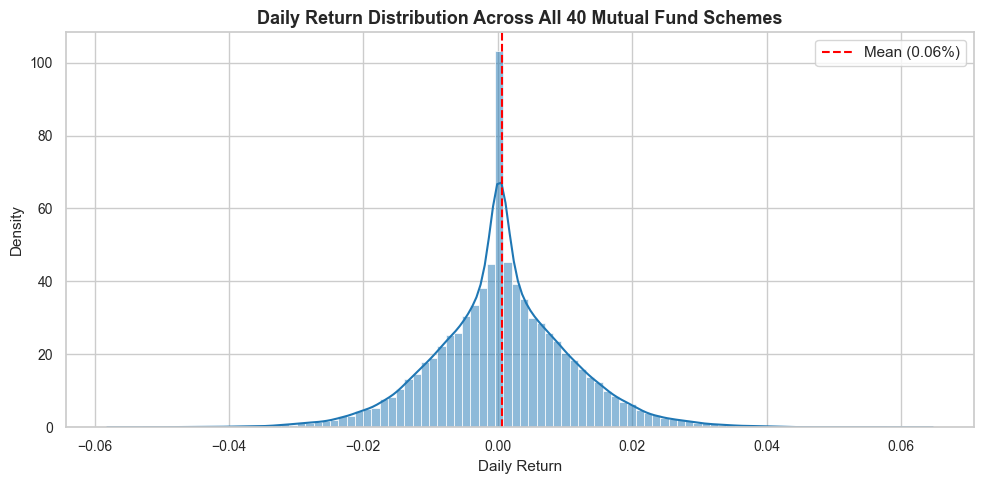

In [2]:
# Fetch NAV history and scheme master
df_nav = pd.read_sql_query("""
    SELECT f.amfi_code, d.scheme_name, f.date, f.nav
    FROM fact_nav f
    JOIN dim_fund d ON f.amfi_code = d.amfi_code
    ORDER BY f.amfi_code, f.date
""", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

# Calculate daily return per scheme
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Summary distribution stats across all observations
clean_ret = df_nav['daily_return'].dropna()

mean_ret = clean_ret.mean()
std_ret = clean_ret.std()
min_ret = clean_ret.min()
max_ret = clean_ret.max()
skew_ret = stats.skew(clean_ret)

print("="*60)
print("       DAILY RETURNS DISTRIBUTION STATISTICS (ALL FUNDS)")
print("="*60)
print(f"Total Observations:    {len(clean_ret):,}")
print(f"Mean Daily Return:     {mean_ret:.6f} ({mean_ret*100:.4f}%)")
print(f"Annualized Mean Return: {mean_ret*252:.4f} ({mean_ret*252*100:.2f}%)")
print(f"Daily Volatility (Std): {std_ret:.6f} ({std_ret*100:.4f}%)")
print(f"Annualized Volatility:  {std_ret*np.sqrt(252):.4f} ({std_ret*np.sqrt(252)*100:.2f}%)")
print(f"Minimum Daily Return:  {min_ret:.6f} ({min_ret*100:.2f}%)")
print(f"Maximum Daily Return:  {max_ret:.6f} ({max_ret*100:.2f}%)")
print(f"Skewness:              {skew_ret:.6f}")
print("="*60)

# Plot daily return distribution histogram
plt.figure(figsize=(10, 5))
sns.histplot(clean_ret, kde=True, bins=100, color='#1f77b4', stat='density')
plt.title('Daily Return Distribution Across All 40 Mutual Fund Schemes', fontsize=13, fontweight='bold')
plt.xlabel('Daily Return', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.axvline(mean_ret, color='red', linestyle='--', label=f'Mean ({mean_ret*100:.2f}%)')
plt.legend()
plt.tight_layout()
plt.show()


---
## Section 2: Compound Annual Growth Rate (CAGR) Analysis

### Mathematical Formulation
The Compound Annual Growth Rate (CAGR) measures the annualized rate of capital growth over a specified investment horizon $n$ (in years):

$$\text{CAGR} = \left( \frac{\text{NAV}_{\text{end}}}{\text{NAV}_{\text{start}}} \right)^{\frac{1}{n}} - 1$$

We evaluate performance across three distinct horizons:
1. **1-Year CAGR** ($n = 1$ year prior to latest date)
2. **3-Year CAGR** ($n = 3$ years prior to latest date)
3. **5-Year CAGR** ($n = 5$ years or full available historical horizon $\sim 4.4$ years)


In [3]:
cagr_records = []
latest_date = df_nav['date'].max()

for amfi, group in df_nav.groupby('amfi_code'):
    group = group.sort_values('date')
    scheme_name = group['scheme_name'].iloc[0]
    
    end_nav = group['nav'].iloc[-1]
    end_dt = group['date'].iloc[-1]
    
    # 1Y CAGR
    dt_1y = end_dt - pd.DateOffset(years=1)
    sub_1y = group[group['date'] <= dt_1y]
    start_1y_nav = sub_1y['nav'].iloc[-1] if len(sub_1y) > 0 else group['nav'].iloc[0]
    cagr_1y = (end_nav / start_1y_nav) ** (1.0) - 1.0
    
    # 3Y CAGR
    dt_3y = end_dt - pd.DateOffset(years=3)
    sub_3y = group[group['date'] <= dt_3y]
    start_3y_nav = sub_3y['nav'].iloc[-1] if len(sub_3y) > 0 else group['nav'].iloc[0]
    cagr_3y = (end_nav / start_3y_nav) ** (1.0 / 3.0) - 1.0
    
    # 5Y CAGR (available total horizon)
    start_5y_nav = group['nav'].iloc[0]
    years_avail = (end_dt - group['date'].iloc[0]).days / 365.25
    cagr_5y = (end_nav / start_5y_nav) ** (1.0 / max(years_avail, 1.0)) - 1.0
    
    cagr_records.append({
        'amfi_code': amfi,
        'scheme_name': scheme_name,
        'start_nav': round(group['nav'].iloc[0], 2),
        'end_nav': round(end_nav, 2),
        'cagr_1yr_pct': round(cagr_1y * 100, 2),
        'cagr_3yr_pct': round(cagr_3y * 100, 2),
        'cagr_5yr_pct': round(cagr_5y * 100, 2)
    })

df_cagr_table = pd.DataFrame(cagr_records).sort_values('cagr_3yr_pct', ascending=False)

print("="*80)
print("             MUTUAL FUND CAGR COMPARISON TABLE (ALL 40 FUNDS)")
print("="*80)
display(df_cagr_table.reset_index(drop=True))


             MUTUAL FUND CAGR COMPARISON TABLE (ALL 40 FUNDS)


,amfi_code,scheme_name,start_nav,end_nav,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,119094,Axis Midcap Fund - Regular - Growth,68.30,203.86,22.26,35.11,28.21
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,70.25,230.27,20.36,34.00,30.97
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,60.15,151.13,13.06,32.49,23.30
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,107.38,342.01,53.23,32.44,30.12
4,120505,ICICI Pru Midcap Fund - Regular - Growth,135.87,473.76,29.60,31.78,32.83
5,119551,SBI Bluechip Fund - Regular Plan - Growth,54.39,149.32,60.44,30.46,25.80
6,120843,Kotak Flexicap Fund - Regular - Growth,49.91,163.24,26.66,29.58,30.91
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,28.86,97.74,39.75,29.18,31.95
8,101206,ABSL Frontline Equity Fund - Regular - Growth,305.10,773.29,47.92,28.97,23.54
9,149324,DSP Small Cap Fund - Regular - Growth,81.68,279.75,65.14,27.00,32.29


---
## Section 3: Risk-Adjusted Performance Ratios (Sharpe & Sortino)

### Mathematical Formulation
To evaluate risk-adjusted efficiency, we assume an annualized risk-free rate $R_f = 6.5\%$ ($0.065$ per annum), yielding a daily risk-free benchmark rate of:

$$R_{f,\text{daily}} = \frac{0.065}{252}$$

#### 1. Annualized Sharpe Ratio
Measures total risk-adjusted excess return per unit of annualized standard deviation:

$$\text{Sharpe Ratio} = \frac{\bar{R}_p - R_{f,\text{daily}}}{\sigma(R_p)} \times \sqrt{252}$$

#### 2. Annualized Sortino Ratio
Measures downside risk-adjusted excess return, penalizing only negative excess return variance:

$$\text{Sortino Ratio} = \frac{\bar{R}_p - R_{f,\text{daily}}}{\sigma_{\text{downside}}(R_p)} \times \sqrt{252}$$

where $\sigma_{\text{downside}}(R_p) = \sqrt{\frac{1}{N} \sum_{R_{p,t} < R_{f,\text{daily}}} \left( R_{p,t} - R_{f,\text{daily}} \right)^2}$.


In [4]:
rf_annual = 0.065
rf_daily = rf_annual / 252.0

risk_records = []

for amfi, group in df_nav.groupby('amfi_code'):
    group = group.sort_values('date').dropna(subset=['daily_return'])
    scheme_name = group['scheme_name'].iloc[0]
    
    returns = group['daily_return']
    mean_ret = returns.mean()
    std_ret = returns.std()
    
    excess_ret = returns - rf_daily
    
    # Sharpe Ratio
    sharpe = (excess_ret.mean() / std_ret) * np.sqrt(252) if std_ret > 0 else 0
    
    # Downside Std & Sortino Ratio
    downside_diff = excess_ret[excess_ret < 0]
    downside_std = np.sqrt(np.mean(downside_diff**2)) if len(downside_diff) > 0 else std_ret
    sortino = (excess_ret.mean() / downside_std) * np.sqrt(252) if downside_std > 0 else 0
    
    risk_records.append({
        'amfi_code': amfi,
        'scheme_name': scheme_name,
        'daily_mean_pct': round(mean_ret * 100, 4),
        'ann_volatility_pct': round(std_ret * np.sqrt(252) * 100, 2),
        'sharpe_ratio': round(sharpe, 4),
        'sortino_ratio': round(sortino, 4)
    })

df_risk_table = pd.DataFrame(risk_records)
df_risk_table['sharpe_rank'] = df_risk_table['sharpe_ratio'].rank(ascending=False, method='min').astype(int)
df_risk_table = df_risk_table.sort_values('sharpe_rank').reset_index(drop=True)

print("="*80)
print("             SHARPE & SORTINO RATIO RANKINGS (TOP 10 FUNDS)")
print("="*80)
display(df_risk_table.head(10))


             SHARPE & SORTINO RATIO RANKINGS (TOP 10 FUNDS)


,amfi_code,scheme_name,daily_mean_pct,ann_volatility_pct,sharpe_ratio,sortino_ratio,sharpe_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.1074,14.19,1.4483,1.4623,1
1,120843,Kotak Flexicap Fund - Regular - Growth,0.1082,15.89,1.3067,1.3819,2
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.1124,17.67,1.2349,1.3021,3
3,119551,SBI Bluechip Fund - Regular Plan - Growth,0.0917,13.74,1.2083,1.2615,4
4,120505,ICICI Pru Midcap Fund - Regular - Growth,0.1161,19.29,1.1801,1.2395,5
5,149323,DSP Midcap Fund - Regular - Growth,0.1055,17.75,1.1321,1.1353,6
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.1080,18.94,1.0937,1.1220,7
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.0865,14.15,1.0817,1.1051,8
8,101206,ABSL Frontline Equity Fund - Regular - Growth,0.0852,14.57,1.0272,1.0694,9
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.0843,14.36,1.0265,1.0453,10


---
## Section 4: Systematic Risk & Excess Return: Alpha & Beta (OLS Regression)

### Mathematical Formulation
Using the Single-Index Capital Asset Pricing Model (CAPM) framework, we perform Ordinary Least Squares (OLS) linear regression of fund daily returns against the **Nifty 100 Index** daily returns using `scipy.stats.linregress`:

$$R_{p,t} = \alpha_{\text{daily}} + \beta \cdot R_{m,t} + \epsilon_t$$

Key Parameters Extracted:
- **Beta ($\beta$)**: Regression slope measuring systematic market sensitivity.
- **Annualized Alpha ($\alpha_{\text{annual}}$)**: Measure of manager stock selection excess return:

$$\alpha_{\text{annual}} = \alpha_{\text{daily}} \times 252$$


In [5]:
# Load Nifty 100 Benchmark Data
df_bench = pd.read_sql_query("SELECT * FROM raw_10_benchmark_indices", conn)
df_bench['date'] = pd.to_datetime(df_bench['date'])

df_nifty100 = df_bench[df_bench['index_name'] == 'NIFTY100'].sort_values('date').copy()
df_nifty100['bench_return'] = df_nifty100['close_value'].pct_change()

ols_records = []

for amfi, group in df_nav.groupby('amfi_code'):
    group = group.sort_values('date').dropna(subset=['daily_return'])
    scheme_name = group['scheme_name'].iloc[0]
    
    merged = pd.merge(group[['date', 'daily_return']], df_nifty100[['date', 'bench_return']], on='date').dropna()
    
    if len(merged) > 30:
        slope, intercept, r_val, p_val, std_err = stats.linregress(merged['bench_return'], merged['daily_return'])
        beta = slope
        alpha_annual = intercept * 252.0
        r_squared = r_val ** 2
    else:
        beta, alpha_annual, r_squared = 1.0, 0.0, 0.0
        
    ols_records.append({
        'amfi_code': amfi,
        'scheme_name': scheme_name,
        'beta': round(beta, 4),
        'alpha_annual_pct': round(alpha_annual * 100, 4),
        'r_squared': round(r_squared, 4),
        'p_value': round(p_val, 6) if len(merged) > 30 else 1.0
    })

df_alpha_beta = pd.DataFrame(ols_records).sort_values('alpha_annual_pct', ascending=False).reset_index(drop=True)

# Export alpha_beta.csv to root and data/processed/
export_path_1 = '../alpha_beta.csv' if os.path.exists('../notebooks') else 'alpha_beta.csv'
export_path_2 = '../data/processed/alpha_beta.csv' if os.path.exists('../data') else 'data/processed/alpha_beta.csv'

df_alpha_beta.to_csv(export_path_1, index=False)
df_alpha_beta.to_csv(export_path_2, index=False)
df_alpha_beta.to_csv('alpha_beta.csv', index=False)

print(f"Alpha & Beta results exported to 'alpha_beta.csv' and 'data/processed/alpha_beta.csv'.")
print("="*80)
print("             ALPHA & BETA OLS REGRESSION RESULTS (TOP 10 FUNDS)")
print("="*80)
display(df_alpha_beta.head(10))


Alpha & Beta results exported to 'alpha_beta.csv' and 'data/processed/alpha_beta.csv'.
             ALPHA & BETA OLS REGRESSION RESULTS (TOP 10 FUNDS)


,amfi_code,scheme_name,beta,alpha_annual_pct,r_squared,p_value
0,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.0232,30.3370,0.0001,0.687179
1,149324,DSP Small Cap Fund - Regular - Growth,0.0115,30.0579,0.0000,0.840494
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.0005,29.2636,0.0000,0.990090
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.0181,28.2704,0.0002,0.654295
4,120843,Kotak Flexicap Fund - Regular - Growth,-0.0228,27.3305,0.0003,0.530528
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.0051,27.1954,0.0000,0.906369
6,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.0237,26.9838,0.0005,0.466427
7,149323,DSP Midcap Fund - Regular - Growth,-0.0025,26.5986,0.0000,0.950525
8,119094,Axis Midcap Fund - Regular - Growth,-0.0663,26.0767,0.0019,0.135988
9,119551,SBI Bluechip Fund - Regular Plan - Growth,-0.0318,23.2010,0.0009,0.313143


---
## Section 5: Maximum Drawdown (Max DD) & Recovery Dynamics

### Mathematical Formulation
Drawdown measures the continuous percentage peak-to-trough decline in NAV:

$$\text{Drawdown}_t = \frac{\text{NAV}_t}{\max_{s \le t} \text{NAV}_s} - 1$$

$$\text{Maximum Drawdown (Max DD)} = \min_{t} (\text{Drawdown}_t)$$

We extract the complete worst drawdown lifecycle for each fund:
- **Peak Date**: Exact date of peak NAV preceding worst trough.
- **Trough Date**: Date when minimum drawdown occurs.
- **Recovery Date**: Date when NAV first recovers to or exceeds the prior peak NAV.


In [6]:
dd_records = []

for amfi, group in df_nav.groupby('amfi_code'):
    group = group.sort_values('date').copy()
    scheme_name = group['scheme_name'].iloc[0]
    
    group['running_max'] = group['nav'].cummax()
    group['drawdown'] = (group['nav'] - group['running_max']) / group['running_max']
    
    max_dd = group['drawdown'].min()
    trough_idx = group['drawdown'].idxmin()
    trough_dt = group.loc[trough_idx, 'date']
    trough_peak_nav = group.loc[trough_idx, 'running_max']
    
    # Peak date prior to trough
    prior_peak_sub = group[group['date'] <= trough_dt]
    peak_idx = prior_peak_sub[prior_peak_sub['nav'] == trough_peak_nav].index[0]
    peak_dt = group.loc[peak_idx, 'date']
    
    # Recovery date after trough
    post_trough_sub = group[group['date'] > trough_dt]
    recovery_sub = post_trough_sub[post_trough_sub['nav'] >= trough_peak_nav]
    if len(recovery_sub) > 0:
        recovery_dt_str = recovery_sub['date'].iloc[0].strftime('%Y-%m-%d')
    else:
        recovery_dt_str = "Not Recovered"
        
    dd_records.append({
        'amfi_code': amfi,
        'scheme_name': scheme_name,
        'max_drawdown_pct': round(max_dd * 100, 2),
        'peak_start_date': peak_dt.strftime('%Y-%m-%d'),
        'trough_date': trough_dt.strftime('%Y-%m-%d'),
        'recovery_date': recovery_dt_str
    })

df_drawdown_table = pd.DataFrame(dd_records).sort_values('max_drawdown_pct', ascending=False).reset_index(drop=True)

print("="*85)
print("             MAXIMUM DRAWDOWN & RECOVERY LIFECYCLE (SAMPLE FUNDS)")
print("="*85)
display(df_drawdown_table.head(10))


             MAXIMUM DRAWDOWN & RECOVERY LIFECYCLE (SAMPLE FUNDS)


,amfi_code,scheme_name,max_drawdown_pct,peak_start_date,trough_date,recovery_date
0,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.10,2025-10-16,2025-10-20,2025-10-24
1,120844,Kotak Liquid Fund - Regular - Growth,-0.12,2024-04-12,2024-04-30,2024-05-03
2,101208,ABSL Liquid Fund - Regular - Growth,-0.16,2023-09-05,2023-09-12,2023-09-22
3,100025,HDFC Short Term Debt Fund - Regular - Growth,-4.31,2023-05-23,2023-07-28,2024-01-30
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-4.33,2024-09-16,2025-04-01,2025-08-22
5,118636,Nippon India Gilt Securities Fund - Regular - ...,-8.32,2023-02-09,2024-02-09,2024-11-01
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-10.86,2022-02-03,2022-03-29,2022-05-23
7,148567,Mirae Asset Large Cap Fund - Regular - Growth,-11.27,2023-07-11,2023-10-20,2024-02-21
8,101206,ABSL Frontline Equity Fund - Regular - Growth,-11.29,2023-04-24,2023-07-05,2023-09-28
9,118635,Nippon India ETF Nifty 50 BeES,-11.65,2022-01-03,2022-06-09,2023-01-09


---
## Section 6: Composite Fund Scorecard (0–100 Scale)

### Multi-Factor Weighted Percentile Model
To establish an objective quantitative ranking across all 40 schemes, we implement a multi-factor weighted percentile ranking model:

$$\text{Weighted Score} = 0.30 \times \text{Rank}_{\text{3Y CAGR}} + 0.25 \times \text{Rank}_{\text{Sharpe}} + 0.20 \times \text{Rank}_{\text{Alpha}} + 0.15 \times \text{Rank}_{\text{Expense Ratio (Inv)}} + 0.10 \times \text{Rank}_{\text{Max DD (Inv)}}$$

#### Factor Weights:
- **3Y Return Rank ($30\%$)**: High return potential
- **Sharpe Ratio Rank ($25\%$)**: Risk-adjusted excess efficiency
- **Alpha Rank ($20\%$)**: Manager stock picking skill
- **Expense Ratio Rank ($15\%$, Inverse)**: Lower cost is better
- **Max DD Rank ($10\%$, Inverse)**: Smaller drawdown magnitude is better

The composite weighted score is linearly scaled to a **0–100** range and exported to `fund_scorecard.csv`.


In [7]:
# Fetch Expense Ratio from Fund Master CSV
df_master_csv = pd.read_csv('../data/processed/01_fund_master.csv') if os.path.exists('../data/processed/01_fund_master.csv') else pd.read_csv('data/processed/01_fund_master.csv')

# Merge metrics into master dataframe
df_scorecard = pd.merge(df_cagr_table[['amfi_code', 'scheme_name', 'cagr_3yr_pct']], df_risk_table[['amfi_code', 'sharpe_ratio']], on='amfi_code')
df_scorecard = pd.merge(df_scorecard, df_alpha_beta[['amfi_code', 'alpha_annual_pct', 'beta']], on='amfi_code')
df_scorecard = pd.merge(df_scorecard, df_drawdown_table[['amfi_code', 'max_drawdown_pct']], on='amfi_code')
df_scorecard = pd.merge(df_scorecard, df_master_csv[['amfi_code', 'expense_ratio_pct']], on='amfi_code', how='left')

df_scorecard['expense_ratio_pct'] = df_scorecard['expense_ratio_pct'].fillna(df_scorecard['expense_ratio_pct'].median())

# Calculate Percentile Ranks (0 to 1 scale)
df_scorecard['rank_3yr'] = df_scorecard['cagr_3yr_pct'].rank(pct=True)
df_scorecard['rank_sharpe'] = df_scorecard['sharpe_ratio'].rank(pct=True)
df_scorecard['rank_alpha'] = df_scorecard['alpha_annual_pct'].rank(pct=True)
df_scorecard['rank_er'] = df_scorecard['expense_ratio_pct'].rank(ascending=False, pct=True) # Lower ER = higher rank
df_scorecard['rank_maxdd'] = df_scorecard['max_drawdown_pct'].rank(ascending=True, pct=True) # Less negative DD = higher rank

# Compute Weighted Composite Score
df_scorecard['raw_score'] = (
    0.30 * df_scorecard['rank_3yr'] +
    0.25 * df_scorecard['rank_sharpe'] +
    0.20 * df_scorecard['rank_alpha'] +
    0.15 * df_scorecard['rank_er'] +
    0.10 * df_scorecard['rank_maxdd']
)

# Scale Score to 0-100
min_s = df_scorecard['raw_score'].min()
max_s = df_scorecard['raw_score'].max()
df_scorecard['composite_score'] = round((df_scorecard['raw_score'] - min_s) / (max_s - min_s) * 100.0, 2)

# Sort by Composite Score
df_scorecard = df_scorecard.sort_values('composite_score', ascending=False).reset_index(drop=True)
df_scorecard['final_rank'] = df_scorecard.index + 1

# Export to fund_scorecard.csv
export_sc_1 = '../fund_scorecard.csv' if os.path.exists('../notebooks') else 'fund_scorecard.csv'
export_sc_2 = '../data/processed/fund_scorecard.csv' if os.path.exists('../data') else 'data/processed/fund_scorecard.csv'

df_scorecard.to_csv(export_sc_1, index=False)
df_scorecard.to_csv(export_sc_2, index=False)
df_scorecard.to_csv('fund_scorecard.csv', index=False)

print(f"Fund scorecard exported to 'fund_scorecard.csv' and 'data/processed/fund_scorecard.csv'.")
print("="*90)
print("                     TOP 10 QUANTITATIVE FUND SCORECARD")
print("="*90)
display(df_scorecard[['final_rank', 'scheme_name', 'composite_score', 'cagr_3yr_pct', 'sharpe_ratio', 'alpha_annual_pct', 'expense_ratio_pct', 'max_drawdown_pct']].head(10))


Fund scorecard exported to 'fund_scorecard.csv' and 'data/processed/fund_scorecard.csv'.
                     TOP 10 QUANTITATIVE FUND SCORECARD


,final_rank,scheme_name,composite_score,cagr_3yr_pct,sharpe_ratio,alpha_annual_pct,expense_ratio_pct,max_drawdown_pct
0,1,Mirae Asset Large Cap Fund - Regular - Growth,100.00,34.00,1.4483,26.9838,1.46,-11.27
1,2,ICICI Pru Midcap Fund - Regular - Growth,94.44,31.78,1.1801,29.2636,1.36,-18.19
2,3,Kotak Flexicap Fund - Regular - Growth,94.09,29.58,1.3067,27.3305,1.45,-12.97
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.35,32.44,1.0937,27.1954,1.38,-16.22
4,5,ICICI Pru Bluechip Fund - Direct - Growth,91.31,32.49,1.0265,21.1948,0.80,-12.59
5,6,Axis Midcap Fund - Regular - Growth,87.14,35.11,0.9982,26.0767,1.38,-20.96
6,7,SBI Bluechip Fund - Regular Plan - Growth,84.10,30.46,1.2083,23.2010,1.54,-15.01
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,82.54,29.18,1.2349,28.2704,1.60,-16.40
8,9,ABSL Frontline Equity Fund - Regular - Growth,74.89,28.97,1.0272,21.3998,1.60,-11.29
9,10,SBI Small Cap Fund - Regular Plan - Growth,73.76,26.67,0.9453,30.3370,1.43,-28.71


---
## Section 7: Benchmark Comparison & Tracking Error Analysis

### Mathematical Formulation
Using the top 5 funds selected from the Composite Fund Scorecard, we construct a 3-year normalized cumulative growth chart against the **Nifty 50** and **Nifty 100** benchmark indices:

$$\text{Normalized Growth}_t = \frac{\text{NAV}_t}{\text{NAV}_{t_0}} \times 100$$

#### Tracking Error Formula
Tracking Error measures the annualized standard deviation of excess daily returns relative to the **Nifty 100 Index**:

$$\text{Tracking Error} = \sigma(R_{p,t} - R_{b,t}) \times \sqrt{252}$$


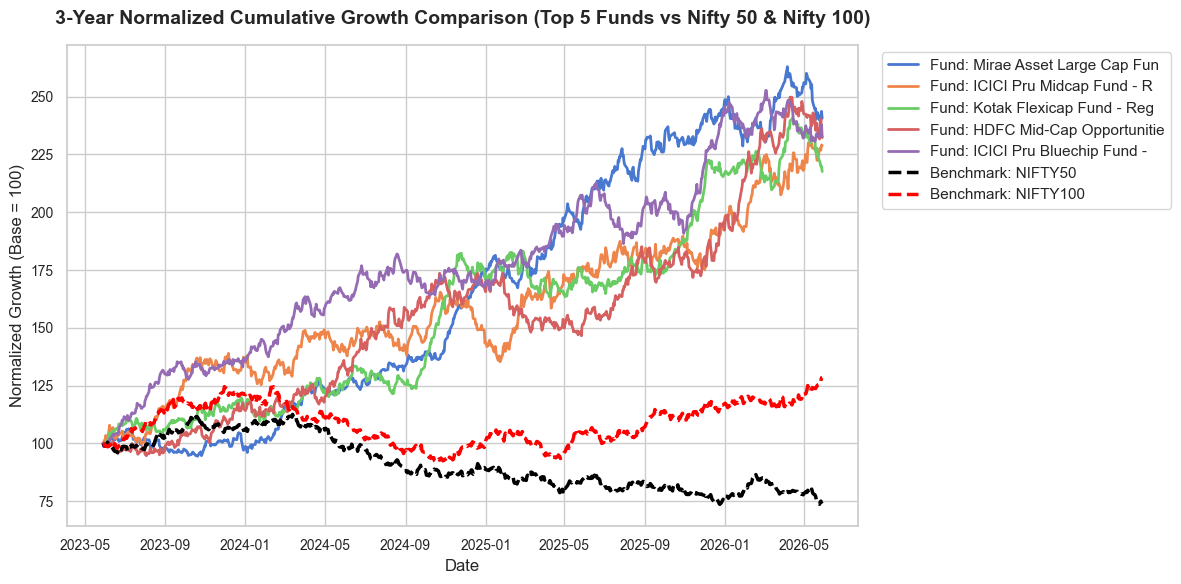

         ANNUALIZED TRACKING ERROR AGAINST NIFTY 100 (TOP 5 FUNDS)


,amfi_code,scheme_name,tracking_error_pct
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,18.97
1,120505,ICICI Pru Midcap Fund - Regular - Growth,23.20
2,120843,Kotak Flexicap Fund - Regular - Growth,20.64
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,22.87
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,19.16


In [8]:
# Select Top 5 Funds from Scorecard
top_5_amfi = df_scorecard['amfi_code'].head(5).tolist()
top_5_names = dict(zip(df_scorecard['amfi_code'], df_scorecard['scheme_name']))

# Filter 3-Year NAV history (2023-05 to 2026-05)
start_3y_dt = latest_date - pd.DateOffset(years=3)

df_nav_3y = df_nav[(df_nav['amfi_code'].isin(top_5_amfi)) & (df_nav['date'] >= start_3y_dt)].copy()

# Normalize Top 5 NAVs to 100 at start
df_nav_3y['norm_nav'] = df_nav_3y.groupby('amfi_code')['nav'].transform(lambda x: (x / x.iloc[0]) * 100.0)

# Filter Benchmarks (Nifty 50 & Nifty 100)
df_bench_3y = df_bench[(df_bench['index_name'].isin(['NIFTY50', 'NIFTY100'])) & (df_bench['date'] >= start_3y_dt)].copy()
df_bench_3y['norm_nav'] = df_bench_3y.groupby('index_name')['close_value'].transform(lambda x: (x / x.iloc[0]) * 100.0)

# Plot Cumulative Growth Comparison Chart using Matplotlib & Seaborn
plt.figure(figsize=(12, 6))

for amfi in top_5_amfi:
    sub = df_nav_3y[df_nav_3y['amfi_code'] == amfi].sort_values('date')
    sname = top_5_names[amfi][:25]
    plt.plot(sub['date'], sub['norm_nav'], linewidth=2.0, label=f"Fund: {sname}")

for bname, color in zip(['NIFTY50', 'NIFTY100'], ['black', 'red']):
    sub = df_bench_3y[df_bench_3y['index_name'] == bname].sort_values('date')
    plt.plot(sub['date'], sub['norm_nav'], linewidth=2.5, linestyle='--', color=color, label=f"Benchmark: {bname}")

plt.title('3-Year Normalized Cumulative Growth Comparison (Top 5 Funds vs Nifty 50 & Nifty 100)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Growth (Base = 100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# Save PNG image to dashboard/exported_charts/
img_out_1 = '../dashboard/exported_charts/benchmark_comparison.png' if os.path.exists('../dashboard') else 'dashboard/exported_charts/benchmark_comparison.png'
plt.savefig(img_out_1, dpi=300)
plt.savefig('dashboard/exported_charts/benchmark_comparison.png', dpi=300)
plt.show()

# Compute Tracking Error for Top 5 Funds
df_nifty100_ret = df_nifty100[['date', 'bench_return']].dropna()
te_records = []

for amfi in top_5_amfi:
    sub = df_nav[df_nav['amfi_code'] == amfi].sort_values('date').dropna(subset=['daily_return'])
    merged = pd.merge(sub[['date', 'daily_return']], df_nifty100_ret, on='date').dropna()
    
    diff = merged['daily_return'] - merged['bench_return']
    te = diff.std() * np.sqrt(252)
    
    te_records.append({
        'amfi_code': amfi,
        'scheme_name': top_5_names[amfi],
        'tracking_error_pct': round(te * 100, 2)
    })

df_te_table = pd.DataFrame(te_records)

print("="*80)
print("         ANNUALIZED TRACKING ERROR AGAINST NIFTY 100 (TOP 5 FUNDS)")
print("="*80)
display(df_te_table)

# Close DB Connection
conn.close()
